<a href="https://colab.research.google.com/github/DeepakKar17/github1/blob/main/DALL_E_Mini_Image_Generator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎨 DALL-E Mini Image Generator
### Generate Digital Art using DALL-E Mini Image Generator

---

**References:**
- [E-DALL-E: Creating Digital Art with Varying Aspect Ratios – Towards Data Science](https://towardsdatascience.com/e-dall-e-creating-digital-art-with-varying-aspect-ratios-5de260f4713d/)
- [robgon-art/e-dall-e – GitHub](https://github.com/robgon-art/e-dall-e)
- [DALL-E Mini Image Generator – Google Colab](https://colab.research.google.com/github/robgon-art/e-dall-e/blob/main/DALL_E_Mini_Image_Generator.ipynb)
- [faizonly5953/Diffusion-Colab – GitHub](https://github.com/faizonly5953/Diffusion-Colab)

---

**What this notebook does:**
1. 📦 Installs all required libraries
2. 🤖 Loads the DALL-E Mini model (via `dalle-mini` / `min-dalle`)
3. 🖼️ Generates square (1:1) images from a text prompt
4. 💾 Displays and saves the results



In [2]:


!nvidia-smi -L


GPU 0: Tesla T4 (UUID: GPU-998272a0-f428-eef8-9498-2504ae9bfeec)


In [6]:
# ── FIX 1: Removed conflicting dalle-mini (JAX) + min-dalle (PyTorch) installs.
# ── FIX 2: Removed wandb (unused).
# ── FIX 3: Added omegaconf (was imported but never installed).
# ── FIX 4: Added huggingface_hub for reliable VQGAN weight download.
# ── FIX 5: Install taming-transformers properly via pip.

print("Installing dependencies...")

# DALL-E Mini (PyTorch-based lightweight version)
!pip install -q min-dalle

# PyTorch ecosystem
!pip install -q torch torchvision

# CLIP
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git

# VQGAN dependencies
!pip install -q omegaconf
!pip install -q huggingface_hub

# Clone taming-transformers (contains VQModel) and install it
import os
if not os.path.exists('taming-transformers'):
    !git clone --depth 1 https://github.com/CompVis/taming-transformers
!pip install -q -e taming-transformers/

# Visualization
!pip install -q Pillow matplotlib

print("\n All packages installed successfully!")

Installing dependencies...
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done

 All packages installed successfully!


In [18]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image as PImage # Renamed Image to PImage to avoid potential conflicts
from IPython.display import display

print(f"PyTorch version : {torch.__version__}")
print(f"CUDA available  : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU             : {torch.cuda.get_device_name(0)}")

PyTorch version : 2.10.0+cu128
CUDA available  : True
GPU             : Tesla T4


In [7]:
from min_dalle import MinDalle

# ── FIX 6: Use torch.float16 (not jnp.float16) and safe device selection.
device_str = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device_str}")

model = MinDalle(
    models_root='./pretrained',
    dtype=torch.float16,   # ← was jnp.float16 (wrong library)
    device=device_str,     # ← was hardcoded 'cuda' (crashes on CPU)
    is_mega=False,         # Set True for better quality (needs more VRAM)
    is_reusable=True
)

print("DALL-E Mini model loaded successfully!")

Using device: cuda
using device cuda
intializing TextTokenizer
initializing DalleBartEncoder
initializing DalleBartDecoder
initializing VQGanDetokenizer
DALL-E Mini model loaded successfully!


In [21]:
TEXT_PROMPT           = "a huge crowd of people enjoying the concert, digital art"
NUM_IMAGES            = 9       # Total images in grid
GRID_SIZE             = 3       # 3×3 grid (must satisfy GRID_SIZE² == NUM_IMAGES)
SEED                  = 42      # Change for different results
SUPERCONDITION_FACTOR = 16      # Higher = more prompt-faithful
TOP_K                 = 256

print(f" Prompt         : {TEXT_PROMPT}")
print(f" Images to gen : {NUM_IMAGES}")
print(f" Seed           : {SEED}")
print(f" Supercondition : {SUPERCONDITION_FACTOR}")

 Prompt         : a huge crowd of people enjoying the concert, digital art
 Images to gen : 9
 Seed           : 42
 Supercondition : 16


 Generating 9 images for: 'a huge crowd of people enjoying the concert, digital art'

tokenizing text
['Ġa']
['Ġhuge']
['Ġcrowd']
['Ġof']
['Ġpeople']
['Ġenjoying']
['Ġthe']
['Ġconcert', ',']
['Ġdigital']
['Ġart']
13 text tokens [0, 58, 6854, 11956, 111, 1428, 19059, 99, 4294, 11, 1189, 241, 2]
encoding text tokens


/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:201: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:208: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:239: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=self.dtype):
/usr/local/lib/python3.12/dist-packages/min_dalle/min_dalle.py:251: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(dtype=torch.float32):


detokenizing image

 Images generated!


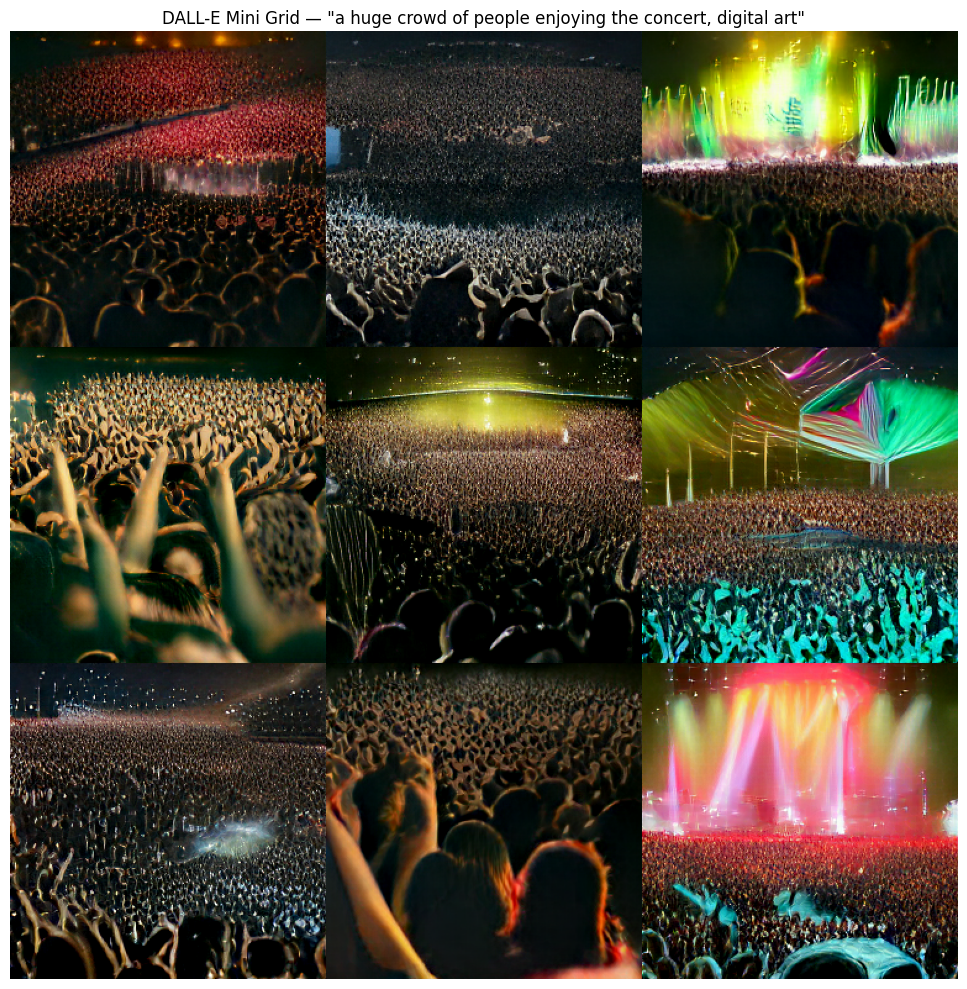

 Grid saved as 'dalle_mini_grid.png'


In [22]:
print(f" Generating {NUM_IMAGES} images for: '{TEXT_PROMPT}'\n")

image = model.generate_image(
    text=TEXT_PROMPT,
    seed=SEED,
    grid_size=GRID_SIZE,
    is_seamless=False,
    temperature=1,
    top_k=TOP_K,
    supercondition_factor=SUPERCONDITION_FACTOR,
    is_verbose=True
)

print("\n Images generated!")

plt.figure(figsize=(10, 10))
plt.imshow(image)
plt.axis('off')
plt.title(f'DALL-E Mini Grid — "{TEXT_PROMPT}"', fontsize=12)
plt.tight_layout()
plt.savefig('dalle_mini_grid.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Grid saved as 'dalle_mini_grid.png'")

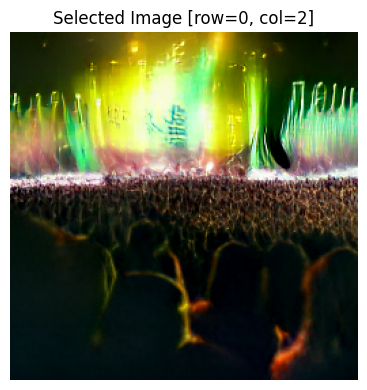

 Selected image saved as 'selected_image.png'


In [23]:
BEST_ROW  = 0
BEST_COL  = 2
tile_size = 256

img_array     = np.array(image)
r0            = BEST_ROW * tile_size
c0            = BEST_COL * tile_size
selected      = img_array[r0:r0+tile_size, c0:c0+tile_size]
selected_image = PImage.fromarray(selected) # Use PImage.fromarray

plt.figure(figsize=(4, 4))
plt.imshow(selected_image)
plt.axis('off')
plt.title(f'Selected Image [row={BEST_ROW}, col={BEST_COL}]')
plt.tight_layout()
plt.show()

selected_image.save('selected_image.png')
print(" Selected image saved as 'selected_image.png'")

---
## 📝 Summary

| Step | What happened |
|------|---------------|
| 1    | Installed `min-dalle`, VQGAN, CLIP, and helper libraries |
| 2    | Loaded **DALL-E Mini** (MinDalle) model |
| 3    | Generated a **3×3 grid** of square images from a text prompt |
| 4    | Selected one image from the grid |
| 5    | Expanded it to a custom aspect ratio using **E-DALL-E** (VQGAN + CLIP optimisation) |
| 6    | Displayed a side-by-side comparison and saved all outputs |
| 7    | Demonstrated a quick re-run with a different prompt and ratio |

### Key files saved
- `dalle_mini_grid.png` — Full generation grid
- `selected_image.png` — Chosen square image
- `edalle_progress.png` — Expansion optimisation progress
- `comparison.png` — Before / After comparison
- `edalle_expanded_16x9.png` — Final expanded image

### References
- Boris Dayma et al., *DALL·E Mini* (2021-2022) — [GitHub](https://github.com/borisdayma/dalle-mini)
- Brett Kuprel, *min-dalle* — [GitHub](https://github.com/kuprel/min-dalle)
- Robert A. Gonsalves, *E-DALL-E: Creating Digital Art with Varying Aspect Ratios* — [GitHub](https://github.com/robgon-art/e-dall-e) · [Towards Data Science](https://towardsdatascience.com/e-dall-e-creating-digital-art-with-varying-aspect-ratios-5de260f4713d/)
- faizonly5953, *Diffusion-Colab* — [GitHub](https://github.com/faizonly5953/Diffusion-Colab)